# Dataset splitting and transformation

### Descripción
NSL-KDD is a dataset used for evaluating intrusion detection systems (IDS) in network security. It contains labeled network traffic data, including both normal activity and different types of attacks. It was created as an improved version of KDD'99 to provide a more reliable benchmark for research, although has some limitations and is not fully representative of real networks. Despite this, it remains a useful benchmark due to the lack of public IDS datasets.

## 1. Reading the dataset

In [ ]:
!pip install liac-arff
import arff
import pandas as pd

In [2]:
def load_kdd_dataset(data_path):
    """Reads the NSL-KDD dataset."""
    with open(data_path, 'r') as train_set:
        dataset = arff.load(train_set)
    attributes = [attr[0] for attr in dataset["attributes"]]
    return pd.DataFrame(dataset["data"], columns=attributes)

In [3]:
df = load_kdd_dataset("KDDTrain+.arff")

## 2. Splitting the dataset

The dataset must be separated into the different subsets necessary to perform the training, validation, and testing processes.

In [4]:
# We split the dataset 60% train set, 40% test set
from sklearn.model_selection import train_test_split

train_set, val_test_set = train_test_split(df, test_size=0.4, random_state=42)

In [5]:
# We split the test dataset 50% validation set, 50% test set
val_set, test_set = train_test_split(val_test_set, test_size=0.5, random_state=42)

In [6]:
print("Dataset Length:", len(df))
print("Training Set Length:", len(train_set))
print("Validation Set Length:", len(val_set))
print("Test Set Length:", len(test_set))

Dataset Length: 125973
Training Set Length: 75583
Validation Set Length: 25195
Test Set Length: 25195


## 3. Random Partitioning and Stratified Sampling

Sklearn implements the **train_test_split** function, however, this function by default performs a random shuffle of the dataset every time the script is executed. To prevent the data from being randomly shuffled, we use the **shuffle** parameter. Used to prevent the model from seeing the future in time ordered datasets.

In [7]:
train_set, test_set = train_test_split(df, test_size=0.4, shuffle=False)

These methods for splitting the dataset are fine if you have a very large dataset, but if you don't, you run the risk of introducing **sampling bias**.

To avoid this, a sampling method called **Stratified sampling** is used. The population is divided into homogeneous subsets called **strata**. The objective is that no characteristic of the dataset is left without representation in any of the datasets for one or more particular characteristics.

Sklearn introduces the **stratify** parameter in the **train_test_split** function to control this behavior.

In [8]:
train_set, val_test_set = train_test_split(df, test_size=0.4, random_state=42, stratify=df["protocol_type"])

In [9]:
val_set, test_set = train_test_split(val_test_set, test_size=0.5, random_state=42, stratify=val_test_set['protocol_type'])

In [36]:
# Divide datasets between entry features and target
X_train = train_set.drop(["class"], axis=1)
y_train = train_set["class"].copy()

X_val = val_set.drop(['class'], axis=1)
y_val = val_set['class']

X_test = test_set.drop(['class'], axis=1)
y_test = test_set['class']

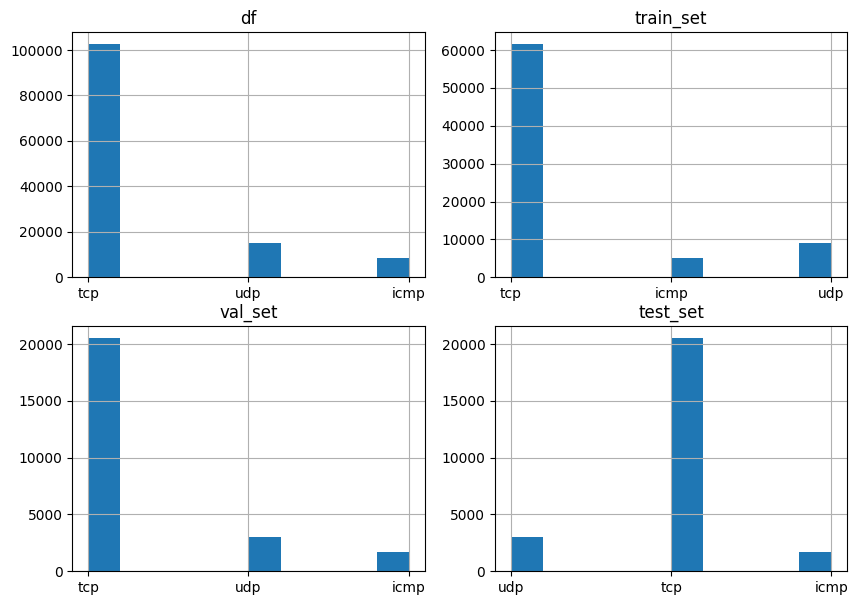

In [11]:
# Checking that stratify maintains the proportion of the feature in the sets
%matplotlib inline
import matplotlib.pyplot as plt
dfs = [df, train_set, val_set, test_set]
titles = ["df", "train_set", "val_set", "test_set"]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()
for ax, d, t in zip(axes, dfs, titles):
    d["protocol_type"].hist(ax=ax)
    ax.set_title(t)
plt.show()

## 4. Dataset cleaning

### 4.1 Missing data analysis

In [18]:
# DataFrame copies
X_train_copy = X_train.copy()

# Induce null values
X_train_copy.loc[(X_train_copy['src_bytes'] > 400) & (X_train_copy['src_bytes'] < 800), ['src_bytes']] = pd.NA
X_train_copy_nonull = X_train_copy.copy()

In [13]:
# 1. Locating null value columns
X_train_copy.isna().any()[X_train_copy.isna().any()].index.tolist()

['src_bytes']

In [14]:
# 2. Counting null rows
len(X_train_copy[X_train_copy.isna().any(axis=1)])

1887

### 4.2 Missing data preprocessing - Null values removal

In [15]:
# Drop the feature column which has null values
X_train_copy_nonull = X_train_copy.drop(['src_bytes'], axis=1)

In [19]:
# Drop the feature null samples
X_train_copy_nonull.dropna(subset=['src_bytes'], inplace=True)

In [ ]:
# Change numeric null values with feature mean or median
X_train_copy_nonull['src_bytes'].fillna(X_train_copy_nonull['src_bytes'].median(), inplace=True)

In [21]:
# Replace numeric null values with SimpleInputer and manual column transformation
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

# Dividing dataframe between object and not object feature values
X_train_copy_obj = X_train_copy.select_dtypes(include=["object"])
X_train_copy_num = X_train_copy.select_dtypes(exclude=["object"]) # Used in this SimpleInputer strategy

# Transforming nulls
X_train_copy_nonull_array = imputer.fit_transform(X_train_copy_num) # Returns an ndarray
X_train_copy_nonull = pd.DataFrame(X_train_copy_nonull_array, columns=X_train_copy_num.columns, index=X_train_copy_num.index)

# Returning original columns and reindexing them
X_train_copy_nonull = pd.concat([X_train_copy_nonull, X_train_copy_obj])
X_train_copy_nonull = X_train_copy_nonull.reindex(X_train_copy.columns, axis=1)

#### Custom transformer to remove rows with null values

In [22]:
from sklearn.base import BaseEstimator, TransformerMixin

class DeleteNullRows(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.dropna()

delete_null_rows = DeleteNullRows()
X_train_copy_nonull = delete_null_rows.fit_transform(X_train_copy)

### 4.2 Encoding - Transform categorical features to numerical

In [23]:
X_train_copy = X_train.copy()

In [24]:
# Ordinal encoding with .factorize() Pandas method
protocol_type_encoded, protocol_type_categories = X_train_copy['protocol_type'].factorize()

for key, value in enumerate(protocol_type_categories):
    print(key,' = ', value)

0  =  tcp
1  =  icmp
2  =  udp


In [25]:
# Ordinal encoding with OrdinalEncoder
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
protocol_type_encoded = ordinal_encoder.fit_transform(X_train_copy[['protocol_type']])

ordinal_encoder.categories_

[array(['icmp', 'tcp', 'udp'], dtype=object)]

In [26]:
# One Hot encoding with .get_dummies()
pd.get_dummies(X_train_copy['protocol_type'], dtype=int) # dtype=int parameter == df.astype(int)

,icmp,tcp,udp
113467,0,1,0
31899,0,1,0
108116,0,1,0
89913,0,1,0
106319,1,0,0
...,...,...,...
64559,0,1,0
67272,0,1,0
32452,0,1,0
112657,0,1,0


In [27]:
# One Hot encoding with OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder(handle_unknown='ignore')
protocol_type_encoded = one_hot_encoder.fit_transform(X_train_copy[['protocol_type']])

protocol_type_encoded.toarray() # Transform from sparse matrix to numpy array

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [28]:
# Dummy Coding (K-1 Encoding) with .get_dummies()
pd.get_dummies(X_train_copy['protocol_type'], drop_first=True, dtype=int)

,tcp,udp
113467,1,0
31899,1,0
108116,1,0
89913,1,0
106319,0,0
...,...,...
64559,1,0
67272,1,0
32452,1,0
112657,1,0


Custom Encoder with OneHotEncoding

In [29]:
from pandas.core.arrays import sparse
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder

class CustomOHEncoder(BaseEstimator, TransformerMixin):
  def __init__(self):
    self.custom_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    self.X_train_copy_objs = None
  def fit(self, X, y=None):
    self.X_train_copy_objs = X.select_dtypes(include=['object'])
    self.custom_encoder.fit(self.X_train_copy_objs)
    return self
  def transform(self, X, y=None):
    X_copy = X.copy()
    X_encoded = self.custom_encoder.transform(X_copy[self.X_train_copy_objs.columns])
    X_encoded = pd.DataFrame(X_encoded, columns=self.custom_encoder.get_feature_names_out(), index=X.index)

    # We can't directly assign X_encoded columns to X_copy ones because Encoding changes the original columns (it increases the number of columns)
    # Delete original categorical columns and replace them with the encoded ones
    X_copy.drop(columns=self.X_train_copy_objs, inplace=True) # In pandas almost no method is destructive unless you set inplace=True or a direct allocation
    X_copy = pd.concat([X_copy, X_encoded], axis=1)
    return X_copy

customEncoder = CustomOHEncoder()
X_train_copy_encoded = customEncoder.fit_transform(X_train_copy_nonull)
X_train_copy_encoded.head()

,duration,src_bytes,dst_bytes,wrong_fragment,urgent,hot,num_failed_logins,num_compromised,root_shell,su_attempted,...,flag_S3,flag_SF,flag_SH,land_0,land_1,logged_in_0,logged_in_1,is_host_login_0,is_guest_login_0,is_guest_login_1
31899,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
108116,0.0,304.0,636.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
89913,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
106319,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
98007,0.0,46.0,139.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0


### 4.3 Scaling - Normalization and Standardization

In [30]:
# Normalization with MinMaxScaler (values between 0 and 1)
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler()
X_train_copy_scaled = min_max_scaler.fit_transform(X_train_copy.select_dtypes(exclude=['object']))

X_train_copy_scaled = pd.DataFrame(X_train_copy_scaled, columns=X_train_copy.select_dtypes(exclude=['object']).columns, index=X_train_copy.index)
X_train_copy_scaled.head()

,duration,src_bytes,dst_bytes,wrong_fragment,urgent,hot,num_failed_logins,num_compromised,root_shell,su_attempted,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
113467,0.0,2.949353e-07,0.000134,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.035294,1.000000,1.00,0.00,0.11,0.03,0.0,0.0,0.0,0.0
31899,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,0.015686,0.02,0.05,0.00,0.00,1.0,1.0,0.0,0.0
108116,0.0,2.202956e-07,0.000002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.152941,1.000000,1.00,0.00,0.03,0.06,0.0,0.0,0.0,0.0
89913,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,0.058824,0.06,0.07,0.00,0.00,1.0,1.0,0.0,0.0
106319,0.0,5.797253e-09,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.007843,0.027451,1.00,0.00,1.00,0.57,0.0,0.0,0.0,0.0


In [31]:
# Standardization with StandardScaler (mean 0 and standard deviation 1)
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
X_train_copy_scaled = standard_scaler.fit_transform(X_train_copy.select_dtypes(exclude=['object']))

X_train_copy_scaled = pd.DataFrame(X_train_copy_scaled, columns=X_train_copy.select_dtypes(exclude=['object']).columns, index=X_train_copy.index)
X_train_copy_scaled.head()

,duration,src_bytes,dst_bytes,wrong_fragment,urgent,hot,num_failed_logins,num_compromised,root_shell,su_attempted,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
113467,-0.109036,-0.008615,0.030988,-0.089994,-0.007062,-0.095215,-0.027013,-0.019379,-0.037652,-0.024683,...,-1.747415,1.259425,1.067358,-0.439274,-0.122385,-0.022050,-0.641690,-0.626894,-0.387526,-0.375287
31899,-0.109036,-0.008669,-0.005713,-0.089994,-0.007062,-0.095215,-0.027013,-0.019379,-0.037652,-0.024683,...,0.732683,-1.007624,-1.115013,-0.174745,-0.479215,-0.289876,1.602592,1.613605,-0.387526,-0.375287
108116,-0.109036,-0.008629,-0.005277,-0.089994,-0.007062,-0.095215,-0.027013,-0.019379,-0.037652,-0.024683,...,-1.444964,1.259425,1.067358,-0.439274,-0.381898,0.245777,-0.641690,-0.626894,-0.387526,-0.375287
89913,-0.109036,-0.008669,-0.005713,-0.089994,-0.007062,-0.095215,-0.027013,-0.019379,-0.037652,-0.024683,...,0.732683,-0.908271,-1.025937,-0.068934,-0.479215,-0.289876,1.602592,1.613605,-0.387526,-0.375287
106319,-0.109036,-0.008668,-0.005713,-0.089994,-0.007062,-0.095215,-0.027013,-0.019379,-0.037652,-0.024683,...,-1.817987,-0.980528,1.067358,-0.439274,2.764697,4.798826,-0.641690,-0.626894,-0.387526,-0.375287


In [32]:
# Standardization with RobustScaler (median and IQR -- robust against outliers)
from sklearn.preprocessing import RobustScaler
robust_scaler = RobustScaler()
X_train_copy_scaled = robust_scaler.fit_transform(X_train_copy.select_dtypes(exclude=['object']))

X_train_copy_scaled = pd.DataFrame(X_train_copy_scaled, columns=X_train_copy.select_dtypes(exclude=['object']).columns, index=X_train_copy.index)
X_train_copy_scaled.head()

,duration,src_bytes,dst_bytes,wrong_fragment,urgent,hot,num_failed_logins,num_compromised,root_shell,su_attempted,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
113467,0.0,1.324818,101.920000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.421965,0.787755,0.515789,-0.428571,1.833333,1.5,0.0,0.0,0.0,0.0
31899,0.0,-0.160584,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,-0.236735,-0.515789,0.285714,0.000000,0.0,1.0,1.0,0.0,0.0
108116,0.0,0.948905,1.211429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.248555,0.787755,0.515789,-0.428571,0.500000,3.0,0.0,0.0,0.0,0.0
89913,0.0,-0.160584,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,-0.191837,-0.473684,0.571429,0.000000,0.0,1.0,1.0,0.0,0.0
106319,0.0,-0.131387,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.462428,-0.224490,0.515789,-0.428571,16.666667,28.5,0.0,0.0,0.0,0.0


#### Custom Scaler with RobustScaler

In [33]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler

class CustomScaler(BaseEstimator, TransformerMixin):
  def __init__(self):
    self.robust_scaler = RobustScaler()
    self.X_train_copy_num = None
  def fit(self, X, y=None):
    self.X_train_copy_num = X_train_copy.select_dtypes(exclude=['object'])
    self.robust_scaler.fit(self.X_train_copy_num)
    return self
  def transform(self, X, y=None):
    X_copy = X.copy()
    X_scaled = self.robust_scaler.transform(X_copy[self.X_train_copy_num.columns])
    X_scaled = pd.DataFrame(X_scaled, columns=self.X_train_copy_num.columns, index=X.index)

    # We directly assign X_scaled columns to X_copy original ones to replace them
    X_copy[X_scaled.columns] = X_scaled
    return X_copy

customScaler = CustomScaler()
X_train_copy_scaled = customScaler.fit_transform(X_train_copy_nonull)
X_train_copy_scaled.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
31899,0.0,tcp,private,S0,-0.160584,0.000000,0,0.0,0.0,0.0,...,0.000000,-0.236735,-0.515789,0.285714,0.000000,0.0,1.0,1.0,0.0,0.0
108116,0.0,tcp,http,SF,0.948905,1.211429,0,0.0,0.0,0.0,...,-1.248555,0.787755,0.515789,-0.428571,0.500000,3.0,0.0,0.0,0.0,0.0
89913,0.0,tcp,private,S0,-0.160584,0.000000,0,0.0,0.0,0.0,...,0.000000,-0.191837,-0.473684,0.571429,0.000000,0.0,1.0,1.0,0.0,0.0
106319,0.0,icmp,eco_i,SF,-0.131387,0.000000,0,0.0,0.0,0.0,...,-1.462428,-0.224490,0.515789,-0.428571,16.666667,28.5,0.0,0.0,0.0,0.0
98007,0.0,udp,domain_u,SF,0.007299,0.264762,0,0.0,0.0,0.0,...,0.000000,0.783673,0.515789,-0.285714,0.000000,0.0,0.0,0.0,0.0,0.0


## 5. Full dataset transformation pipeline

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# Dataset column transformations (Transform null values --> Encoding categorical columns
# (ColumnTransformer automatically replaces old with new encoded columns) --> Scaling dataset)
class DataTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.full_pipeline = None

    def fit(self, X, y=None):
        num_cols = X.select_dtypes(include=['number']).columns
        cat_cols = X.select_dtypes(exclude=['number']).columns

        self.full_pipeline = ColumnTransformer([
        ('num', Pipeline([
            ('num_imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('cat_imputer', SimpleImputer(strategy='most_frequent')),
            ('oh_encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
        ])

        self.full_pipeline.fit(X)
        return self

    def transform(self, X, y=None):
        return pd.DataFrame(self.full_pipeline.transform(X), columns=self.full_pipeline.get_feature_names_out(), index=X.index)

data_transformer = DataTransformer()
X_train_prepared = data_transformer.fit_transform(X_train)
X_val_prepared = data_transformer.transform(X_val)
X_test_prepared = data_transformer.transform(X_test)
X_train_prepared.head()


,num__duration,num__src_bytes,num__dst_bytes,num__wrong_fragment,num__urgent,num__hot,num__num_failed_logins,num__num_compromised,num__root_shell,num__su_attempted,...,cat__flag_S3,cat__flag_SF,cat__flag_SH,cat__land_0,cat__land_1,cat__logged_in_0,cat__logged_in_1,cat__is_host_login_0,cat__is_guest_login_0,cat__is_guest_login_1
113467,0.0,1.324818,101.920000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
31899,0.0,-0.160584,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
108116,0.0,0.948905,1.211429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
89913,0.0,-0.160584,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
106319,0.0,-0.131387,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0


## 5. Model training

In [38]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_prepared, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

## 6. Model evaluation

In [41]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

y_val_pred = clf.predict(X_val_prepared)
print("ACCURACY: ", accuracy_score(y_val, y_val_pred)) # proportion of correct predictions out of all predictions
print("RECALL: ", recall_score(y_val, y_val_pred, pos_label="anomaly")) # proportion of positives that were correctly identified
print("PRECISION: ", precision_score(y_val, y_val_pred, pos_label="anomaly")) # proportion of predicted positives that really were positives
print("F1-SCORE: ", f1_score(y_val, y_val_pred, pos_label="anomaly")) # harmonic mean of precision and recall balancing bothdife

ACCURACY:  0.9682873586028974
RECALL:  0.9579403517716034
PRECISION:  0.9737433062705131
F1-SCORE:  0.9657771876472352


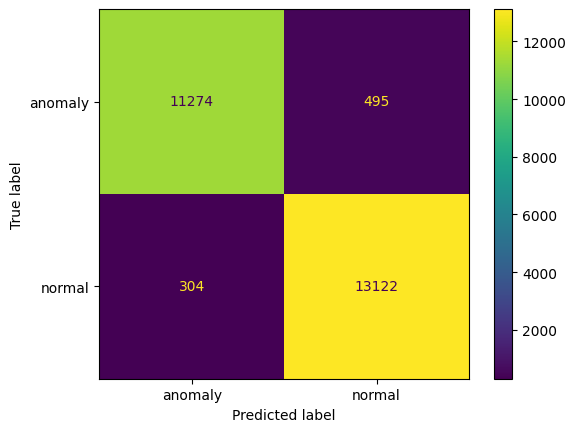

In [42]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix(y_val, y_val_pred), display_labels=np.unique(y_val)).plot()

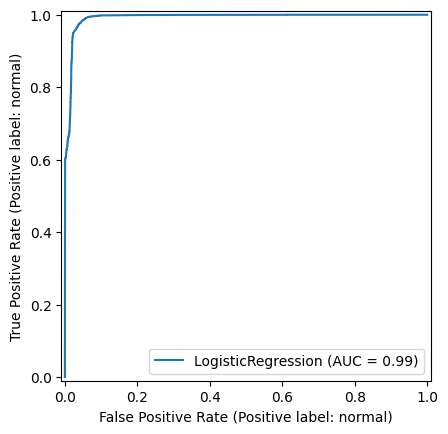

In [43]:
# ROC Curve
from sklearn.metrics import roc_curve, RocCurveDisplay

RocCurveDisplay.from_estimator(clf, X_val_prepared, y_val)

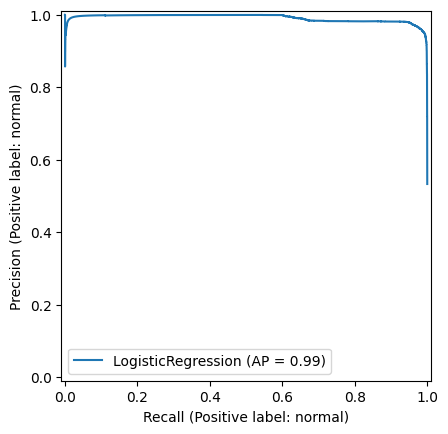

In [44]:
# Precision Recall Curve
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(clf, X_val_prepared, y_val)
plt.show()